In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

print("OpenCV Version:", cv2.__version__)

OpenCV Version: 4.13.0


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yaseenksk/dataset-panorama")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset-panorama' dataset.
Path to dataset files: /kaggle/input/dataset-panorama


In [ ]:
import os

dataset_path = path

image_paths = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg", ".png", ".jpeg")):

            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

for img in image_paths[:10]:
    print(img)

Total images found: 70
/kaggle/input/dataset-panorama/dataset/image003.png
/kaggle/input/dataset-panorama/dataset/image037.png
/kaggle/input/dataset-panorama/dataset/image021.png
/kaggle/input/dataset-panorama/dataset/image040.png
/kaggle/input/dataset-panorama/dataset/image036.png
/kaggle/input/dataset-panorama/dataset/image012.png
/kaggle/input/dataset-panorama/dataset/image020.png
/kaggle/input/dataset-panorama/dataset/image039.png
/kaggle/input/dataset-panorama/dataset/image014.png
/kaggle/input/dataset-panorama/dataset/image034.png


# Check Overlap

In [ ]:
selected_images = sorted(image_paths)[:6]

print("Selected images for stitching:")

for img in selected_images:
    print(img)

Selected images for stitching:
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/Panorama1.jpg
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/panorama2.jpg
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/panorama_1642752959802.jpg
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/panorama_1642792636950.jpg
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/panorama_1642838401683.jpg
/kaggle/input/dataset-panorama/dataset/Panorama_dataset/panorama_1642838458385.jpg


In [ ]:
loaded_images = []

for img_path in selected_images:

    img = cv2.imread(img_path)

    if img is not None:
        loaded_images.append(img)

print("Images loaded:", len(loaded_images))

Images loaded: 6


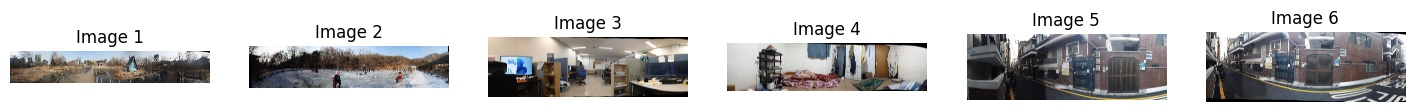

In [ ]:
plt.figure(figsize=(18,6))

for i, img in enumerate(loaded_images):

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(loaded_images), i+1)
    plt.imshow(rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [ ]:
orb = cv2.ORB_create(nfeatures=2000)

In [ ]:
def detect_features(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    keypoints, descriptors = orb.detectAndCompute(gray, None)

    return keypoints, descriptors

In [ ]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

In [ ]:
def visualize_overlap(img1, img2):

    kp1, des1 = detect_features(img1)
    kp2, des2 = detect_features(img2)

    matches = bf.match(des1, des2)

    matches = sorted(matches, key=lambda x: x.distance)

    matched_img = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:50],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16,6))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

Matching Image 1 and Image 2


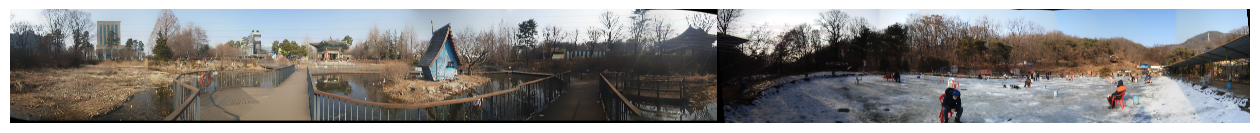

Matching Image 2 and Image 3


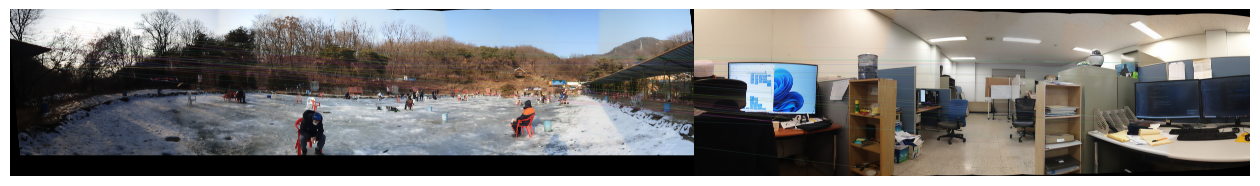

Matching Image 3 and Image 4


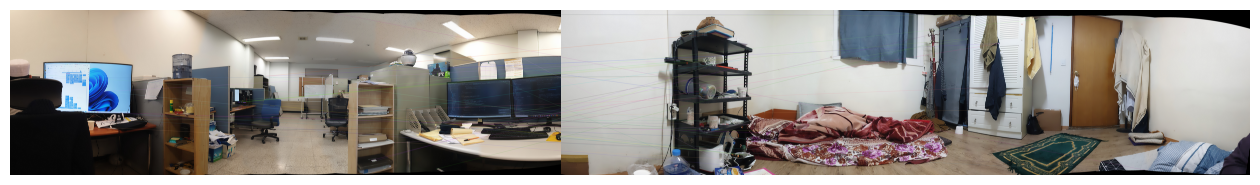

Matching Image 4 and Image 5


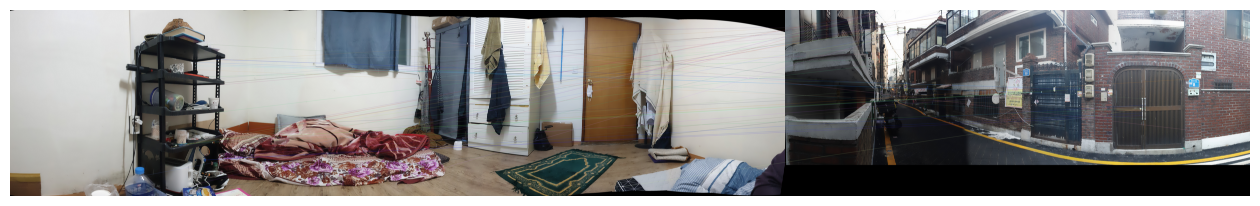

Matching Image 5 and Image 6


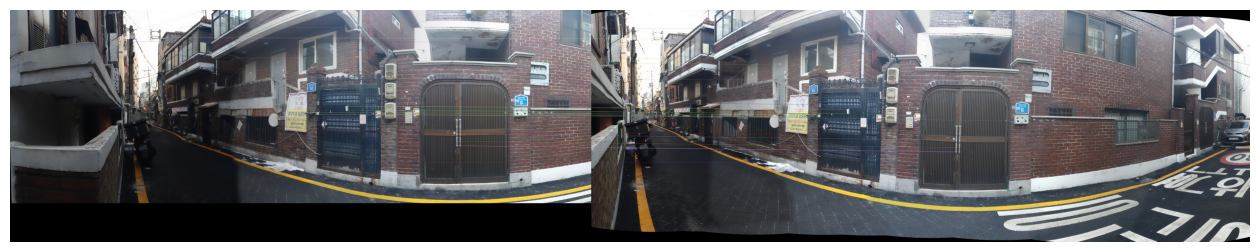

In [ ]:
for i in range(len(loaded_images) - 1):

    print(f"Matching Image {i+1} and Image {i+2}")

    visualize_overlap(
        loaded_images[i],
        loaded_images[i+1]
    )

In [ ]:
dataset_images_path = os.path.join(dataset_path, "dataset")

print(dataset_images_path)

/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset


In [ ]:
for scene, imgs in scene_groups.items():
    print(scene, "→", len(imgs), "images")

dataset → 40 images
Panorama_dataset → 30 images


In [ ]:
image_paths = []

for file in sorted(os.listdir(dataset_images_path)):

    if file.lower().endswith((".png",".jpg",".jpeg")):

        image_paths.append(os.path.join(dataset_images_path,file))

print("Total images found:", len(image_paths))

for img in image_paths:
    print(img)

Total images found: 40
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image001.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image002.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image003.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image004.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image005.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image006.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image007.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image008.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image009.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image010.png
/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions

In [ ]:
loaded_images = []

for img_path in image_paths:

    img = cv2.imread(img_path)

    if img is not None:
        loaded_images.append(img)

print("Loaded images:", len(loaded_images))

Loaded images: 40


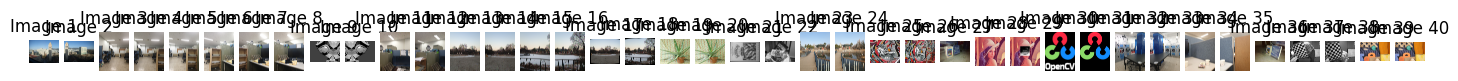

In [ ]:
plt.figure(figsize=(18,6))

for i, img in enumerate(loaded_images):

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,len(loaded_images),i+1)
    plt.imshow(rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

# Manual Panorama Stitching Pipeline.

### Step 1 — Initialize ORB Detector



In [ ]:
orb = cv2.ORB_create(nfeatures=3000)

### Step 2 — Detect Features in Two Images

In [ ]:
img1 = loaded_images[0]
img2 = loaded_images[1]

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Keypoints Image1:", len(kp1))
print("Keypoints Image2:", len(kp2))

Keypoints Image1: 2827
Keypoints Image2: 2819


### Step 3 — Match Features (BFMatcher)

In [ ]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

### Step 4 — Apply Lowe Ratio Test

In [ ]:
good_matches = []

for m, n in matches:

    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

Good matches: 809


### Step 5 — Visualize Good Matches

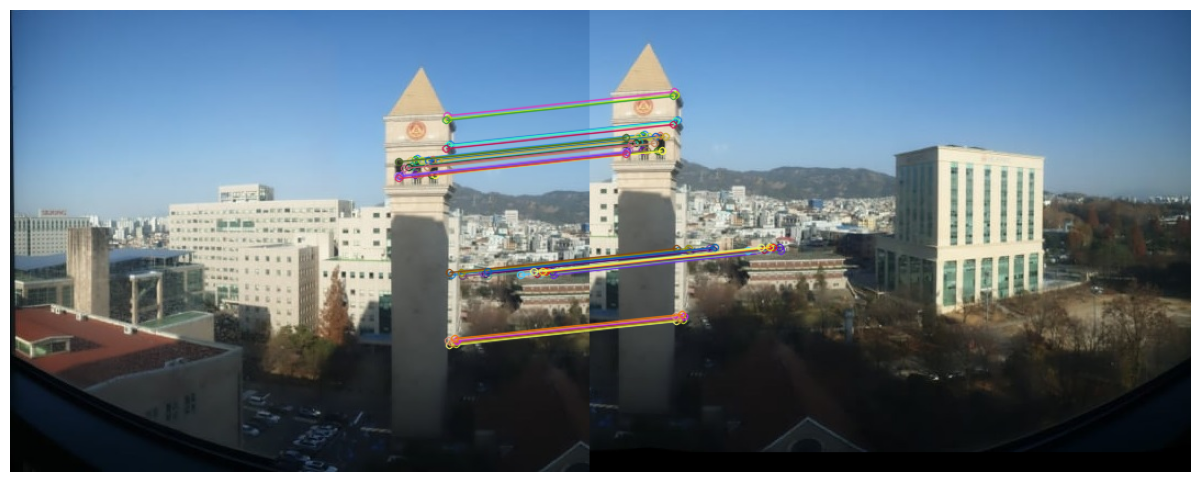

In [ ]:
match_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Step 6 — Compute Homography (RANSAC)

In [ ]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 1.01015924e+00  1.04984030e-03 -3.24653306e+02]
 [ 2.30134546e-03  1.01231025e+00 -2.36839911e+01]
 [ 1.68760866e-05  1.27352583e-05  1.00000000e+00]]


In [ ]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

# create large canvas
canvas_width = w1 + w2
canvas_height = max(h1, h2)

# place img2 on canvas
panorama = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)
panorama[0:h2, 0:w2] = img2

# warp img1 into panorama space
warped_img1 = cv2.warpPerspective(img1, H, (canvas_width, canvas_height))

# merge images
mask = (warped_img1 > 0)
panorama[mask] = warped_img1[mask]

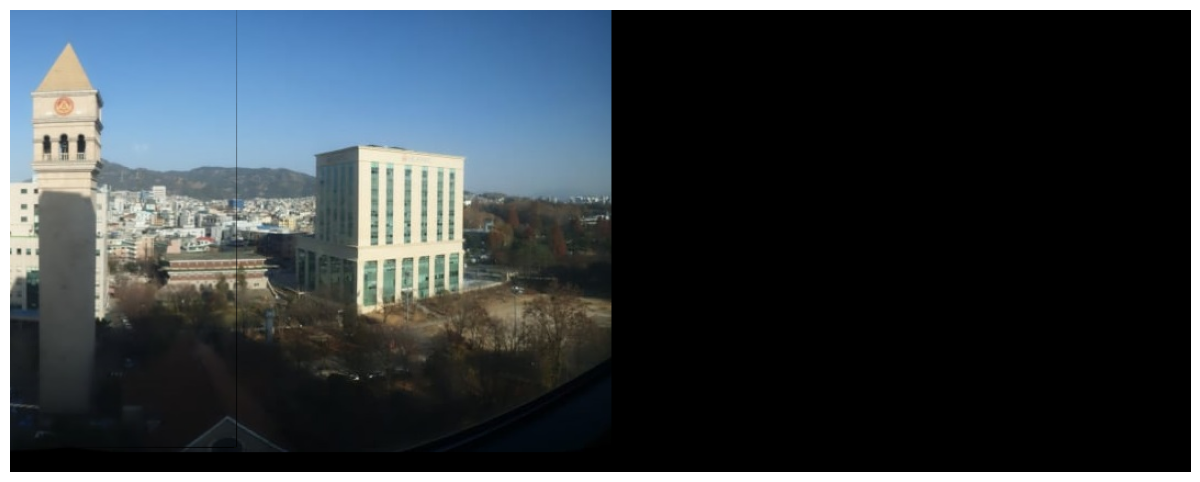

In [ ]:
plt.figure(figsize=(16,6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# PART 3 - OPEN CV

### Step 1 — Create OpenCV Stitcher (PANORAMA Mode)

In [ ]:
print("Running OpenCV Stitcher (PANORAMA mode)...")

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

Running OpenCV Stitcher (PANORAMA mode)...


In [ ]:
dataset_images_path = path + "/dataset"

In [ ]:
dataset_root = "/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1"

In [ ]:
import os
dataset_images_path = os.path.join(dataset_root, "dataset")

print(dataset_images_path)

/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset


In [ ]:
image_paths = sorted([
    os.path.join(dataset_images_path, f)
    for f in os.listdir(dataset_images_path)
    if f.lower().endswith((".png",".jpg",".jpeg"))
])

print("Found images:", len(image_paths))
print(image_paths)

Found images: 40
['/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image001.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image002.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image003.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image004.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image005.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image006.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image007.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image008.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image009.png', '/root/.cache/kagglehub/datasets/yaseenksk/dataset-panorama/versions/1/dataset/image010.png', '/root/.cache/kagglehub/datasets/yaseenksk

In [ ]:
images = []

for p in image_paths:

    img = cv2.imread(p)

    if img is not None:
        images.append(img)

print("Loaded images:", len(images))

Loaded images: 40


In [ ]:
images_resized = []

for img in images:

    h, w = img.shape[:2]

    scale = 800 / max(h, w)   # keep aspect ratio

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    images_resized.append(resized)

print("Images resized:", len(images_resized))

Images resized: 40


In [ ]:
for i,img in enumerate(images_resized):
    print("Image", i, "shape:", img.shape)

Image 0 shape: (637, 800, 3)
Image 1 shape: (588, 800, 3)
Image 2 shape: (800, 600, 3)
Image 3 shape: (800, 600, 3)
Image 4 shape: (800, 600, 3)
Image 5 shape: (800, 600, 3)
Image 6 shape: (800, 600, 3)
Image 7 shape: (800, 600, 3)
Image 8 shape: (600, 800, 3)
Image 9 shape: (600, 800, 3)
Image 10 shape: (800, 600, 3)
Image 11 shape: (800, 600, 3)
Image 12 shape: (800, 600, 3)
Image 13 shape: (800, 600, 3)
Image 14 shape: (800, 600, 3)
Image 15 shape: (800, 600, 3)
Image 16 shape: (693, 800, 3)
Image 17 shape: (719, 800, 3)
Image 18 shape: (692, 800, 3)
Image 19 shape: (692, 800, 3)
Image 20 shape: (550, 800, 3)
Image 21 shape: (600, 800, 3)
Image 22 shape: (800, 600, 3)
Image 23 shape: (800, 600, 3)
Image 24 shape: (640, 800, 3)
Image 25 shape: (640, 800, 3)
Image 26 shape: (600, 800, 3)
Image 27 shape: (800, 800, 3)
Image 28 shape: (800, 800, 3)
Image 29 shape: (800, 605, 3)
Image 30 shape: (800, 604, 3)
Image 31 shape: (800, 600, 3)
Image 32 shape: (800, 600, 3)
Image 33 shape: (800

In [ ]:
subset = images_resized[:2]

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

status, pano = stitcher.stitch(subset)

print("Status:", status)

Status: 0


Stitching successful


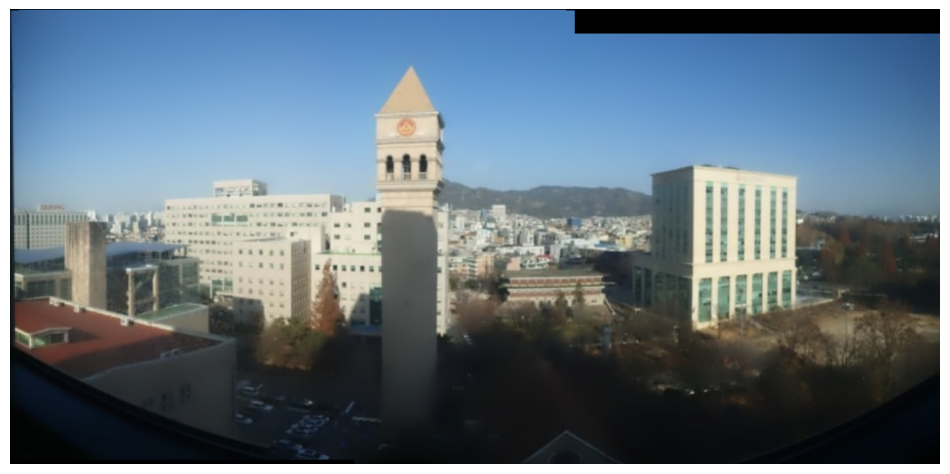

In [ ]:
if status == cv2.Stitcher_OK:

    print("Stitching successful")

    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

else:

    print("Stitching failed with code:", status)

In [ ]:
subset = images_resized[:3]

status, pano = stitcher.stitch(subset)

In [ ]:
for i in range(len(images_resized)-1):

    print("Testing pair:", i, "and", i+1)

    stitcher = cv2.Stitcher_create()

    status, _ = stitcher.stitch([images_resized[i], images_resized[i+1]])

    print("Status:", status)

Testing pair: 0 and 1
Status: 0
Testing pair: 1 and 2
Status: 1
Testing pair: 2 and 3
Status: 0
Testing pair: 3 and 4
Status: 0
Testing pair: 4 and 5
Status: 0
Testing pair: 5 and 6
Status: 0
Testing pair: 6 and 7
Status: 0
Testing pair: 7 and 8
Status: 1
Testing pair: 8 and 9
Status: 0
Testing pair: 9 and 10
Status: 1
Testing pair: 10 and 11
Status: 0
Testing pair: 11 and 12
Status: 1
Testing pair: 12 and 13
Status: 0
Testing pair: 13 and 14
Status: 1
Testing pair: 14 and 15
Status: 1
Testing pair: 15 and 16
Status: 1
Testing pair: 16 and 17
Status: 1
Testing pair: 17 and 18
Status: 1
Testing pair: 18 and 19
Status: 0
Testing pair: 19 and 20
Status: 1
Testing pair: 20 and 21
Status: 0
Testing pair: 21 and 22
Status: 1
Testing pair: 22 and 23
Status: 0
Testing pair: 23 and 24
Status: 1
Testing pair: 24 and 25
Status: 3
Testing pair: 25 and 26
Status: 1
Testing pair: 26 and 27
Status: 1
Testing pair: 27 and 28
Status: 3
Testing pair: 28 and 29
Status: 1
Testing pair: 29 and 30
Status: 1

In [ ]:
subset = images_resized[:3]

Failed at image


(np.float64(-0.5), np.float64(1290.5), np.float64(630.5), np.float64(-0.5))

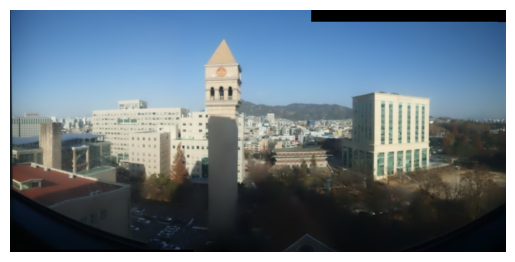

In [ ]:
panorama = images_resized[0]

for img in images_resized[1:3]:

    stitcher = cv2.Stitcher_create()

    status, pano = stitcher.stitch([panorama, img])

    if status == cv2.Stitcher_OK:
        panorama = pano
    else:
        print("Failed at image")

plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")

# PART 3 -- DEEPSTICH


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
import cv2
import numpy as np
import os

class AdvancedStitcher:

    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.images = []

    def load_and_preprocess(self, scale=0.4):

        files = sorted([
            f for f in os.listdir(self.folder_path)
            if f.lower().endswith(('.jpg','.png','.jpeg'))
        ])

        for f in files:

            img_path = os.path.join(self.folder_path, f)
            img = cv2.imread(img_path)

            if img is not None:

                h, w = img.shape[:2]

                img = cv2.resize(img,(int(w*scale),int(h*scale)))

                self.images.append(img)

        print(f"Loaded {len(self.images)} images from {self.folder_path}")


    def stitch_advanced(self, mode="PANORAMA"):

        mode_val = cv2.Stitcher_PANORAMA if mode=="PANORAMA" else cv2.Stitcher_SCANS

        stitcher = cv2.Stitcher_create(mode_val)

        print("Starting stitching...")

        status, result = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:

            return self.post_process(result)

        else:

            print("Stitching failed. Status:", status)
            return None


    def post_process(self, image):

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        _,mask = cv2.threshold(gray,1,255,cv2.THRESH_BINARY)

        coords = cv2.findNonZero(mask)

        x,y,w,h = cv2.boundingRect(coords)

        return image[y:y+h, x:x+w]

In [ ]:
    def get_features(self, img):

        akaze = cv2.AKAZE_create()

        kp, des = akaze.detectAndCompute(img, None)

        return kp, des

In [ ]:
    def stitch_advanced(self, mode="PANORAMA"):

        if mode == "PANORAMA":
            mode_val = cv2.Stitcher_PANORAMA
        else:
            mode_val = cv2.Stitcher_SCANS

        stitcher = cv2.Stitcher_create(mode_val)

        print(f"Starting advanced {mode} stitching...")

        status, result = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:

            return self.post_process(result)

        else:

            print("Stitching failed with status:", status)

            return None

In [ ]:
    def post_process(self, image):

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

        contours = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )[0]

        if contours:

            c = max(contours, key=cv2.contourArea)

            x,y,w,h = cv2.boundingRect(c)

            image = image[y:y+h, x:x+w]

        return image

In [ ]:
dataset_folder = "/kaggle/input/dataset-panorama/dataset"

my_stitcher = AdvancedStitcher(dataset_folder)

# Load and resize images
my_stitcher.load_and_preprocess(scale=0.4)

# Use only first 10 images
my_stitcher.images = my_stitcher.images[:10]

print("Using", len(my_stitcher.images), "images for stitching")

# Run panorama stitching
final_result = my_stitcher.stitch_advanced(mode="PANORAMA")

Loaded 40 images from /kaggle/input/dataset-panorama/dataset
Using 10 images for stitching
Starting stitching...


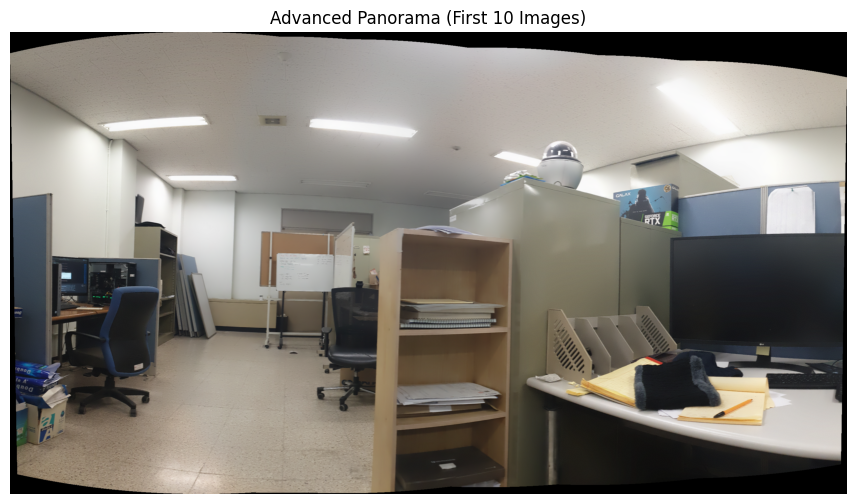

In [ ]:
import matplotlib.pyplot as plt

if final_result is not None:

    plt.figure(figsize=(14,6))
    plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Advanced Panorama (First 10 Images)")
    plt.show()

    cv2.imwrite("advanced_panorama_10_images.jpg", final_result)

In [ ]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

canvas_width = w1 + w2
canvas_height = max(h1, h2)

# warp img1
warped_img1 = cv2.warpPerspective(img1, H, (canvas_width, canvas_height))

# copy img2
panorama = warped_img1.copy()
panorama[0:h2, 0:w2] = img2

In [ ]:
gray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

coords = cv2.findNonZero(thresh)
x, y, w, h = cv2.boundingRect(coords)

panorama = panorama[y:y+h, x:x+w]

In [ ]:
cv2.imwrite("orb_panorama_result.jpg", panorama)

True

In [ ]:
from google.colab import files
files.download("orb_panorama_result.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("ORB Panorama Result")
plt.show()